In [2]:
!pip install datasets

In [3]:
import pandas as pd
import re
from datasets import Dataset

# 1. Load training and test data from CSV files
df_train = pd.read_csv("train.csv", encoding="iso-8859-1")
df_test = pd.read_csv("test.csv", encoding="iso-8859-1")

# Keep only required columns and remove missing values
df_train = df_train[['text', 'sentiment']].dropna()
df_test = df_test[['text', 'sentiment']].dropna()

# 2. Convert sentiment labels into numbers (needed for model training)
sentiment_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df_train['label'] = df_train['sentiment'].map(sentiment_map)
df_test['label'] = df_test['sentiment'].map(sentiment_map)

# 3. Function to clean text data
def clean_text(text):
    text = str(text).lower()                 # Convert to lowercase
    text = re.sub(r'\s+', ' ', text)         # Remove extra spaces
    text = re.sub(r'[^a-z0-9\s]', '', text)  # Remove special characters
    return text

# Apply cleaning to both datasets
df_train['text'] = df_train['text'].apply(clean_text)
df_test['text'] = df_test['text'].apply(clean_text)

print(f"Total training samples: {len(df_train)}")
print(f"Total test samples: {len(df_test)}")

Total training samples: 27480
Total test samples: 3534


In [4]:
from transformers import AutoTokenizer

# Load the DistilBERT tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_function(examples):
    # Convert text into tokens, keep length fixed for faster training
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

# Convert pandas data into Hugging Face dataset format
train_dataset = Dataset.from_pandas(df_train[['text', 'label']])
test_dataset = Dataset.from_pandas(df_test[['text', 'label']])

# Apply tokenization on both datasets
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

print("Tokenization done. Data is ready for the model.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/27480 [00:00<?, ? examples/s]

Map:   0%|          | 0/3534 [00:00<?, ? examples/s]

Tokenization done. Data is ready for the model.


In [5]:
import numpy as np
import evaluate
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

# Load accuracy metric to evaluate model performance
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)  # Get predicted class
    return accuracy_metric.compute(predictions=predictions, references=labels)

# Load pre-trained DistilBERT model for 3-class classification
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=3)

# Set training configuration
training_args = TrainingArguments(
    output_dir="./sentiment_model",
    eval_strategy="epoch",        # Check performance after every epoch
    save_strategy="epoch",
    learning_rate=2e-5,           # Typical learning rate for fine-tuning
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,           # Train for 3 full passes over data
    weight_decay=0.01,
    load_best_model_at_end=True   # Keep the best model automatically
)

# Set up Trainer with model, data, and settings
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics
)

print("Training started... Fine-tuning the model.")
trainer.train()

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training started... Fine-tuning the model.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.568529,0.532083,0.785512
2,0.452708,0.559907,0.780419
3,0.353800,0.594988,0.780702


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=5154, training_loss=0.4675482623004432, metrics={'train_runtime': 951.0462, 'train_samples_per_second': 86.683, 'train_steps_per_second': 5.419, 'total_flos': 2730201774704640.0, 'train_loss': 0.4675482623004432, 'epoch': 3.0})


=== MODEL PERFORMANCE REPORT ===
              precision    recall  f1-score   support

    Negative       0.81      0.75      0.78      1001
     Neutral       0.72      0.81      0.76      1430
    Positive       0.87      0.78      0.82      1103

    accuracy                           0.78      3534
   macro avg       0.80      0.78      0.79      3534
weighted avg       0.79      0.78      0.79      3534


=== CONFUSION MATRIX ===


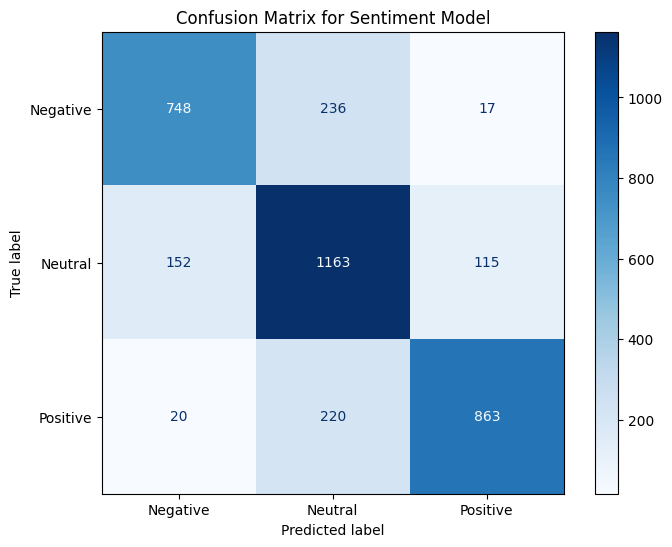

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# 1. Get predictions from the trained model on test data
predictions = trainer.predict(tokenized_test)
preds = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids

# Class names for display
target_names = ['Negative', 'Neutral', 'Positive']

# 2. Show classification report (precision, recall, f1-score)
print("\n=== MODEL PERFORMANCE REPORT ===")
print(classification_report(true_labels, preds, target_names=target_names))

# 3. Show confusion matrix to understand prediction distribution
print("\n=== CONFUSION MATRIX ===")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    true_labels,
    preds,
    display_labels=target_names,
    cmap=plt.cm.Blues,
    ax=ax
)

plt.title("Confusion Matrix for Sentiment Model")
plt.show()